In [1]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics


Map: 100%|██████████| 7600/7600 [00:00<00:00, 28031.34 examples/s]
/opt/anaconda3/envs/kd_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[[1799   20   49   32]
 [   7 1884    6    3]
 [  32    9 1741  118]
 [  35   11  103 1751]]
World: World=0.947, Sports=0.011, Business=0.026, Sci/Tech=0.017
Sports: World=0.004, Sports=0.992, Business=0.003, Sci/Tech=0.002
Business: World=0.017, Sports=0.005, Business=0.916, Sci/Tech=0.062
Sci/Tech: World=0.018, Sports=0.006, Business=0.054, Sci/Tech=0.922


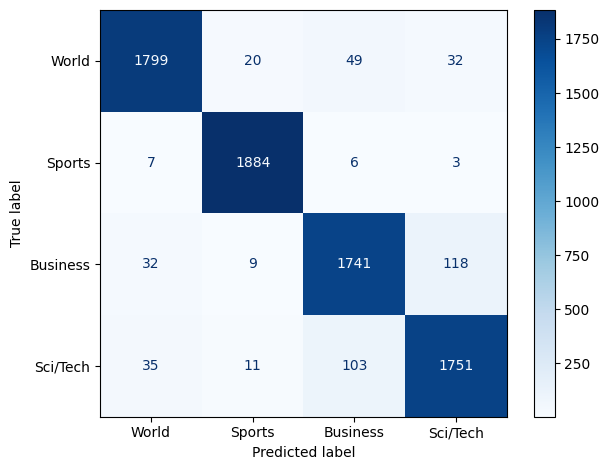

In [11]:
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

MODEL_PATH = "../models/bert_teacher"
LABELS = ["World", "Sports", "Business", "Sci/Tech"]

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

test_ds = load_dataset("fancyzhx/ag_news", split="test")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

test_ds = test_ds.map(tokenize, batched=True)
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

trainer = Trainer(model=model)
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)
print(cm)

# Normalized by true class, so you can see % of each class misrouted elsewhere
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
for i, label in enumerate(LABELS):
    print(f"{label}: " + ", ".join(f"{LABELS[j]}={cm_norm[i,j]:.3f}" for j in range(4)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
